# Experiment II — Combination Portfolio

This notebook studies the additive combination map

$$
w(\alpha)=(1-\alpha)w_{eq}+\alpha w_{sig},
\qquad
w_{sig}=\frac{\Sigma^{-1}s}{\mathbf 1^\top\Sigma^{-1}s}.
$$

Experiment II(a) varies the overall strength $\alpha$, Experiment II(b) changes drift-signal quality, and Experiment II(c) introduces a volatility signal alongside the drift signal. The notebook then contains Experiment III, which compares the combination and Gibbs softmax maps directly under common and heterogeneous volatility.

The combination map uses covariance information and may produce negative weights or leverage. At $\alpha=0$ it returns equal weight, while $\alpha=1$ reaches the normalised signal-implied portfolio $w_{sig}$. Because $w_{sig}$ is a ratio, the map becomes ill-conditioned when its normaliser approaches zero. The simulations therefore state the domain rule explicitly and use common retained samples for head-to-head comparisons.

## Model and simulation design

Returns, drift signals, baseline parameters, and random-number streams match Experiment I. The common performance criterion is

$$
\mathrm{CE}_{MV}(P)=\mathbb E[P]-\frac{\gamma}{2}\operatorname{Var}(P),\qquad \gamma=5,
$$

reported in basis points relative to equal weight. This criterion allows the long-only and shortable portfolios to be assessed using the same finite measure.

The signal-implied portfolio is defined only when $\mathbf 1^\top\Sigma^{-1}s\neq0$. To avoid numerical behaviour dominated by draws arbitrarily close to this pole, a setting retains replications satisfying

$$
\left|\mathbf 1^\top\Sigma^{-1}s\right|>
0.10\,\operatorname{median}\left|\mathbf 1^\top\Sigma^{-1}s\right|.
$$

This is a domain restriction rather than ordinary outlier removal: the reported performance is conditional on the normaliser remaining sufficiently far from zero. When several signal or covariance settings are compared, the intersection of their masks is used so that every alternative is evaluated on the same replications. The same common mask is applied to softmax in direct comparisons.

Within a fixed retained sample, portfolio returns are affine in $\alpha$, making the sample M--V CE curve quadratic. Common random numbers are used throughout so changes across strength, noise, covariance, and signal processing are paired.

In [65]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names (until Experiment II(c))
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # mean--variance risk coefficient
n_sims   = 30_000    # Monte-Carlo replications

alpha_grid     = np.linspace(0.0, 2.0, 201)   # strength grid; alpha = 1 reaches the signal-optimal leg
alpha_grid_ext = np.linspace(0.0, 5.0, 251)   # extended grid for near-clean signals (Experiment II(b))
beta_grid      = np.linspace(0.0, 120.0, 121) # softmax grid of Experiment I, for head-to-heads


mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # standardised Brownian increments

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

In [66]:
def combination_weights(s, alpha, Sigma_inv=None):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    w_sig = num / num.sum(axis=1, keepdims=True)
    return (1.0 - alpha) / N + alpha * w_sig

def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_mv(port):
    return port.mean() - 0.5 * gamma * port.var(ddof=0)

def normaliser_mask_from_num(num, frac=0.10):
    ns = num.sum(axis=1)
    return np.abs(ns) > frac * np.median(np.abs(ns))

def valid_mask(s, Sigma_inv=None, frac=0.10):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    return normaliser_mask_from_num(num, frac)

def mv_blend_curve(p_eq, p_sig, grid):
    """Exact sample CE_MV curve for p(alpha)=p_eq+alpha*(p_sig-p_eq)."""
    d = p_sig - p_eq
    dm, p0m = d.mean(), p_eq.mean()
    cov = np.mean((p_eq - p0m) * (d - dm))
    vd = d.var(ddof=0)
    return ce_mv(p_eq) + grid * (dm - gamma * cov) - 0.5 * gamma * grid**2 * vd

def ce_sweep(s, grid, R_mat, Sigma_inv=None):
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    w_sig = num / num.sum(axis=1, keepdims=True)
    p_eq, p_sig = R_mat.mean(axis=1), (w_sig * R_mat).sum(axis=1)
    CE = mv_blend_curve(p_eq, p_sig, grid)
    SHORT, LEV = np.empty(len(grid)), np.empty(len(grid))
    for k, a in enumerate(grid):
        w = (1.0-a)/N + a*w_sig
        SHORT[k] = np.abs(np.minimum(w, 0.0)).sum(axis=1).mean()
        LEV[k] = np.abs(w).sum(axis=1).mean()
    return CE, SHORT, LEV

def ce_of(w, R_mat):
    return ce_mv((w * R_mat).sum(axis=1))

def alpha_star(grid, CE):
    k = int(np.argmax(CE))
    return grid[k], CE[k], k

def best_alpha(num, R_mat, grid, mask=None):
    own = normaliser_mask_from_num(num)
    m = own if mask is None else mask
    ns = num[m].sum(axis=1)
    w_sig = num[m] / ns[:, None]
    p_eq, p_sig = R_mat[m].mean(axis=1), (w_sig * R_mat[m]).sum(axis=1)
    curve = mv_blend_curve(p_eq, p_sig, grid)
    k = int(np.argmax(curve))
    return 1e4*(curve[k]-curve[0]), grid[k], int((~own).sum())

def portfolio_from_num(num, alpha, R_mat, mask):
    ns = num[mask].sum(axis=1)
    p_eq = R_mat[mask].mean(axis=1)
    p_sig = ((num[mask]/ns[:,None]) * R_mat[mask]).sum(axis=1)
    return (1-alpha)*p_eq + alpha*p_sig

def paired_block_ce(p_a, p_b, n_blocks=6):
    vals=[]
    for ix in np.array_split(np.arange(len(p_a)), n_blocks):
        vals.append(1e4*(ce_mv(p_a[ix])-ce_mv(p_b[ix])))
    vals=np.asarray(vals)
    return vals.mean(), vals.std(ddof=1)/np.sqrt(len(vals))


## Experiment II(a) — Strength sweep

The baseline drift-signal noise is fixed at $\sigma_\varepsilon=0.05$ while $\alpha$ is varied over the strength grid. The experiment tests whether the best combination portfolio lies between equal weight and $w_{sig}$, reaches $w_{sig}$ at $\alpha=1$, or extrapolates beyond it.

Two checks anchor the path. First, the implementation at $\alpha=1$ must reproduce $w_{sig}$ exactly. Second, near equal weight the combination and softmax maps have the same first-order direction under the per-replication conversion between $\alpha$ and $\beta$. The cell reports the CE curve and the selected $\alpha^*$ together with short exposure, gross leverage, entropy deficit, and paired Monte-Carlo diagnostics.

normaliser domain rule: retained 29959 and dropped 41 of 30000
alpha=1 vs signal tangency-direction proxy: max |difference| = 0.00e+00
alpha=0.05: dCE_MV comb= 28.1 bp | per-draw softmax= 28.2 bp | fixed-beta softmax= 24.5 bp
alpha=0.1: dCE_MV comb= 55.2 bp | per-draw softmax= 55.1 bp | fixed-beta softmax= 48.4 bp


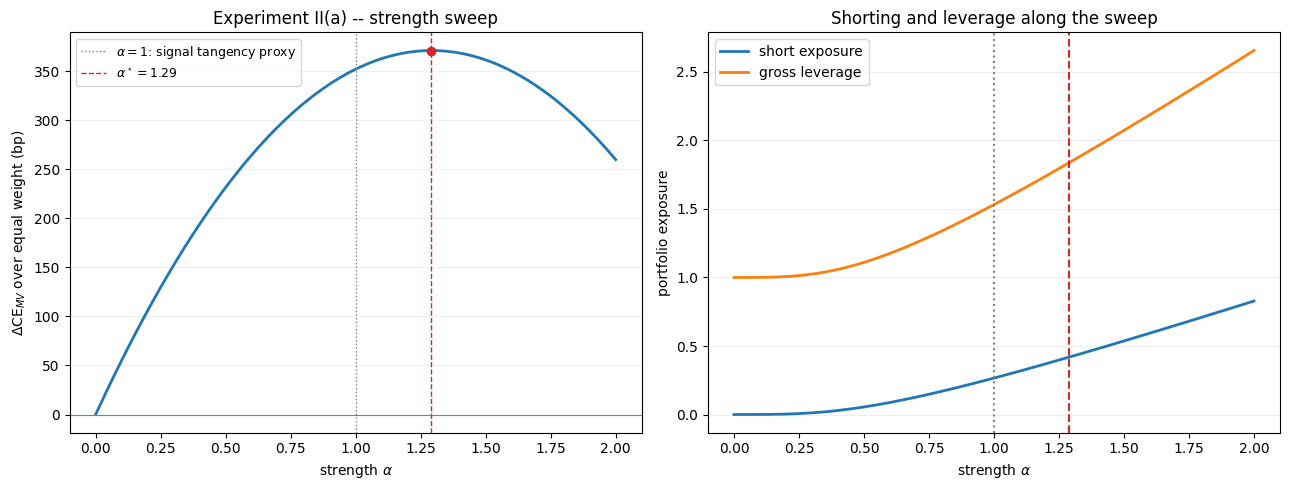


alpha*=1.29; CE_MV gain=370.9 bp; paired MC SE=9.5 bp
at alpha*: short exposure=0.42, gross leverage=1.84

normaliser-threshold sensitivity
 threshold   dropped   alpha*   peak dCE_MV
        5%        16     1.13         325.2
       10%        41     1.29         370.9
       20%       145     1.43         402.5


In [67]:
sigma_eps_base = 0.05
s_base = mu + sigma_eps_base * eps0
mask = valid_mask(s_base)
sm, Rm = s_base[mask], R[mask]
print(f"normaliser domain rule: retained {mask.sum()} and dropped {(~mask).sum()} of {n_sims}")

CE_a, SHORT_a, LEV_a = ce_sweep(sm, alpha_grid, Rm)
astar, _, k = alpha_star(alpha_grid, CE_a)
dCE_a = 1e4*(CE_a-CE_a[0])

w1 = combination_weights(sm, 1.0)
w_sig = sm/sm.sum(axis=1,keepdims=True)
print(f"alpha=1 vs signal tangency-direction proxy: max |difference| = {np.abs(w1-w_sig).max():.2e}")

sbar = sm.mean(axis=1,keepdims=True)
for a_chk in [0.05,0.10]:
    ce_c=ce_of(combination_weights(sm,a_chk),Rm)
    z=(a_chk/sbar)*sm; z-=z.max(axis=1,keepdims=True); e=np.exp(z)
    ce_sd=ce_of(e/e.sum(axis=1,keepdims=True),Rm)
    ce_fx=ce_of(softmax_weights(sm,a_chk/mu_bar),Rm)
    print(f"alpha={a_chk}: dCE_MV comb={1e4*(ce_c-CE_a[0]):5.1f} bp | per-draw softmax="
          f"{1e4*(ce_sd-CE_a[0]):5.1f} bp | fixed-beta softmax={1e4*(ce_fx-CE_a[0]):5.1f} bp")

fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]; ax.plot(alpha_grid,dCE_a,lw=2); ax.axhline(0,color='grey',lw=.8)
ax.axvline(1,color='grey',ls=':',lw=1,label=r'$\alpha=1$: signal tangency proxy')
ax.axvline(astar,color='tab:red',ls='--',lw=1,label=fr'$\alpha^\star={astar:.2f}$')
ax.scatter([astar],[dCE_a[k]],color='tab:red',zorder=5)
ax.set(xlabel=r'strength $\alpha$',ylabel=r'$\Delta$CE$_{MV}$ over equal weight (bp)',title='Experiment II(a) -- strength sweep')
ax.grid(axis='y',alpha=.2); ax.legend(fontsize=9)
ax=axes[1]; ax.plot(alpha_grid,SHORT_a,lw=2,label='short exposure'); ax.plot(alpha_grid,LEV_a,lw=2,label='gross leverage')
ax.axvline(astar,color='tab:red',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'strength $\alpha$',ylabel='portfolio exposure',title='Shorting and leverage along the sweep')
ax.grid(axis='y',alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

p0=Rm.mean(axis=1); pstar=(combination_weights(sm,astar)*Rm).sum(axis=1)
_,se_star=paired_block_ce(pstar,p0)
print(f"\nalpha*={astar:.2f}; CE_MV gain={dCE_a[k]:.1f} bp; paired MC SE={se_star:.1f} bp")
print(f"at alpha*: short exposure={SHORT_a[k]:.2f}, gross leverage={LEV_a[k]:.2f}")
print("\nnormaliser-threshold sensitivity")
print(f"{'threshold':>10}{'dropped':>10}{'alpha*':>9}{'peak dCE_MV':>14}")
for thr in [0.05,0.10,0.20]:
    mt=valid_mask(s_base,frac=thr); ce_t,_,_=ce_sweep(s_base[mt],alpha_grid,R[mt]); at,_,kt=alpha_star(alpha_grid,ce_t)
    print(f"{thr:>10.0%}{(~mt).sum():>10}{at:>9.2f}{1e4*(ce_t[kt]-ce_t[0]):>14.1f}")


### Supporting P&L diagnostics

Representative strength values are evaluated using mean return, volatility, probability of loss, downside quantiles, short exposure, and gross leverage. These diagnostics show how the portfolio changes along the additive path while M--V CE remains the criterion used to select strength.

 alpha     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
  0.00    5.29%    4.91%    14.0%     -2.63%           --       0.0
  1.00   11.06%   10.70%    11.2%     -3.73%        77.2%     351.9
  1.29   12.74%   13.19%    12.3%     -5.02%        77.2%     370.9
  1.50   13.95%   15.04%    12.9%     -5.98%        77.2%     361.3
  2.00   16.84%   19.56%    14.3%     -8.62%        77.2%     259.8


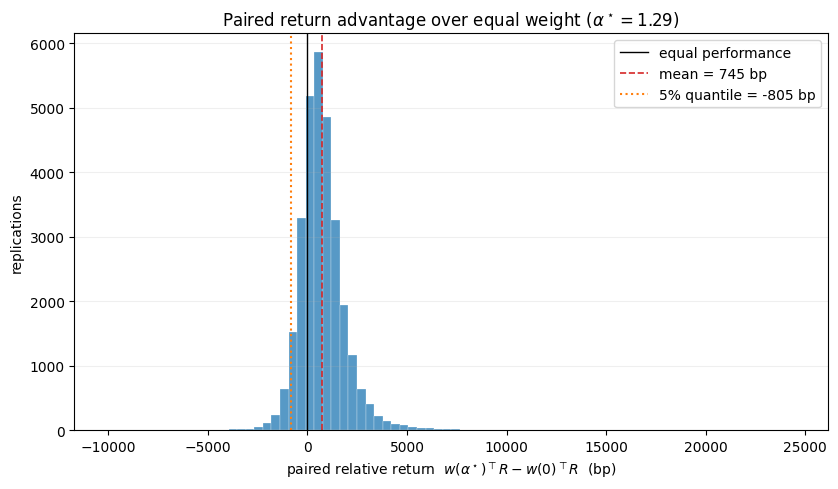

P(combination beats 1/N) = 77.2%
mean relative return = 745 bp,  5% quantile = -805 bp


In [68]:
alphas_show = [0.0, 1.0, astar, 1.5, 2.0]

ports, rows = {}, []
for a in alphas_show:
    w = combination_weights(sm, a)
    p = (w * Rm).sum(axis=1)
    ports[a] = p
    ce = ce_of(w, Rm)
    rows.append((a, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if a > 0 else np.nan,
                 1e4 * (ce - CE_a[0])))

print(f"{'alpha':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>10} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for a, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{a:>6.2f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>10.2%} {pb_s} {dce:>9.1f}")

d = ports[astar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\alpha^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\alpha^\star = {astar:.2f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(combination beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

### Invariance checks

Softmax is shift-invariant: adding the same constant to every score leaves its weights unchanged. The combination map is scale-invariant but not shift-invariant:

$$
\frac{\Sigma^{-1}(cs)}{\mathbf 1^\top\Sigma^{-1}(cs)}
=
\frac{\Sigma^{-1}s}{\mathbf 1^\top\Sigma^{-1}s},
$$

whereas replacing $s$ by $s+c\mathbf 1$ changes both the numerator and normaliser. The following cell verifies these properties numerically and traces the combination path under several common score shifts. It also records what happens when the signal is demeaned, a case in which the normaliser is deliberately moved towards zero.

softmax under shifts: max |weight difference| = 5.55e-16


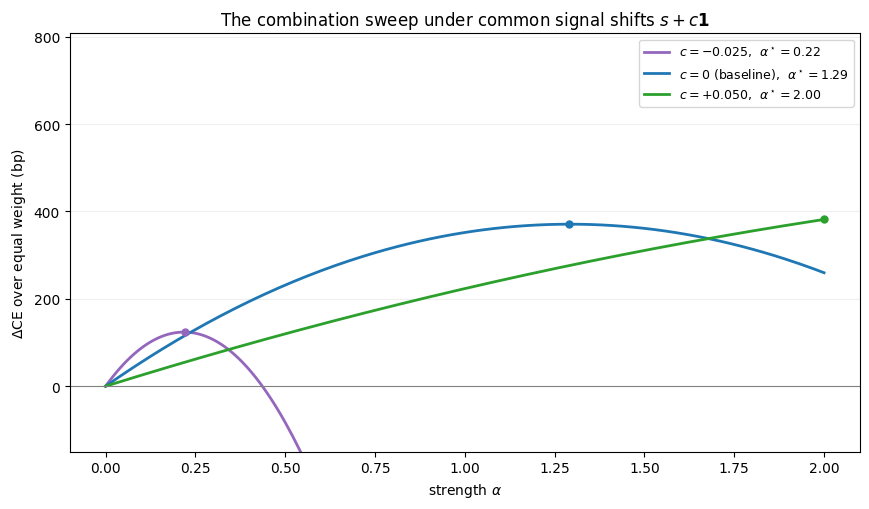

demeaned signal (c = -mu_bar): normaliser negative on 50.0% of draws; the 10% rule excludes 5.4%


In [69]:
c_shifts = [-0.025, 0.0, +0.05]

w_ref = softmax_weights(sm, 21.0)
max_dev = max(np.abs(softmax_weights(sm + c, 21.0) - w_ref).max() for c in c_shifts if c != 0)
print(f"softmax under shifts: max |weight difference| = {max_dev:.2e}")

fig, ax = plt.subplots(figsize=(8.8, 5.2))
for c, col in zip(c_shifts, ['tab:purple', 'tab:blue', 'tab:green']):
    s_c    = s_base + c
    mask_c = valid_mask(s_c)
    CE_c, _, _ = ce_sweep(s_c[mask_c], alpha_grid, R[mask_c])
    a_c, _, k_c = alpha_star(alpha_grid, CE_c)
    lbl = (r'$c=0$ (baseline)' if c == 0 else fr'$c={c:+.3f}$') + fr',  $\alpha^\star={a_c:.2f}$'
    ax.plot(alpha_grid, 1e4 * (CE_c - CE_c[0]), lw=2, color=col, label=lbl)
    ax.scatter([a_c], [1e4 * (CE_c[k_c] - CE_c[0])], color=col, zorder=5, s=25)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'The combination sweep under common signal shifts $s + c\mathbf{1}$')
ax.set_ylim(-150, None)
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

s_dm = s_base - mu_bar
ns_dm = s_dm.sum(axis=1)
print(f"demeaned signal (c = -mu_bar): normaliser negative on {(ns_dm < 0).mean():.1%} of draws; "
      f"the 10% rule excludes {(~valid_mask(s_dm)).mean():.1%}")

## Experiment II(b) — Signal quality

The drift-signal noise level is varied over the same ladder as in Experiment I(b), and $\alpha$ is re-optimised at every level. All settings are evaluated on the intersection of their normaliser masks, ensuring that changes in reported CE do not arise from comparing different retained samples.

The Gaussian reliability coefficient

$$
\kappa=\frac{\sigma_\mu^2}{\sigma_\mu^2+\sigma_\varepsilon^2}
$$

provides the benchmark $\alpha^*_{clean}\kappa$. This benchmark reflects shrinkage of the drift signal towards its prior centre. For the combination map it is only approximate because changing the signal also changes its random normaliser and the resulting leverage. The output reports the optimal strength, peak M--V CE gain, retained sample, and leverage diagnostics across the complete noise ladder.

common comparison sample: retained 27809, dropped 2191


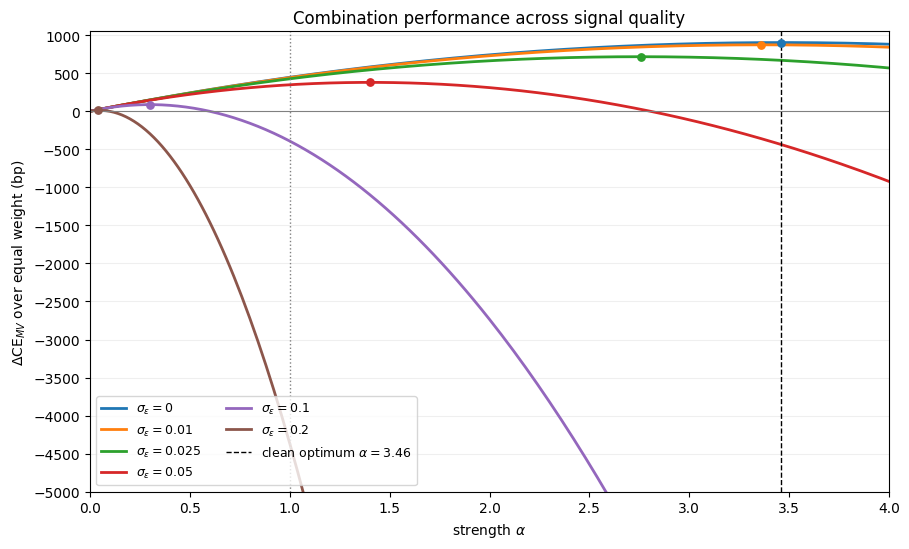

 sigma_eps   alpha*  kappa pred   peak dCE_MV  own drops    MC SE
       0.0     3.46        3.46         902.5          0     25.1
      0.01     3.36        3.33         872.8          0     24.8
     0.025     2.76        2.77         716.6          1     18.0
      0.05     1.40        1.73         379.2         41     12.4
       0.1     0.30        0.69          87.2        649      3.5
       0.2     0.04        0.20          10.8       1503      0.6


In [70]:
sigma_eps_levels=[0.0,0.01,0.025,0.05,0.10,0.20]
signals35={se:mu+se*eps0 for se in sigma_eps_levels}
masks35={se:valid_mask(s) for se,s in signals35.items()}
common35=np.logical_and.reduce(list(masks35.values()))
print(f"common comparison sample: retained {common35.sum()}, dropped {(~common35).sum()}")
results35={}
for se,s_l in signals35.items():
    ce_l,_,_=ce_sweep(s_l[common35],alpha_grid_ext,R[common35])
    results35[se]=(ce_l,int((~masks35[se]).sum()))

astars35=np.array([alpha_star(alpha_grid_ext,results35[se][0])[0] for se in sigma_eps_levels])
kappa=sigma_mu**2/(sigma_mu**2+np.array(sigma_eps_levels)**2); pred=astars35[0]*kappa

fig,ax=plt.subplots(figsize=(9.2,5.6))
for se in sigma_eps_levels:
    ce_l,_=results35[se]
    dce=1e4*(ce_l-ce_l[0])
    line,=ax.plot(alpha_grid_ext,dce,lw=2,label=fr'$\sigma_\varepsilon={se:g}$')
    kk=int(np.argmax(dce))
    ax.scatter(alpha_grid_ext[kk],dce[kk],s=28,color=line.get_color(),zorder=4)
ax.axhline(0,color='grey',lw=.8)
ax.axvline(1,color='grey',ls=':',lw=1)
ax.axvline(astars35[0],color='black',ls='--',lw=1,label=fr'clean optimum $\alpha={astars35[0]:.2f}$')
ax.set_xlim(0,4); ax.set_ylim(-5000,1050)
ax.set_yticks(np.arange(-5000,1001,500))
ax.set(xlabel=r'strength $\alpha$',ylabel=r'$\Delta$CE$_{MV}$ over equal weight (bp)',title='Combination performance across signal quality')
ax.grid(axis='y',alpha=.2); ax.legend(fontsize=9,ncol=2,loc='lower left')
plt.tight_layout()
plt.savefig('experiment5_signal_quality_report.png',dpi=300,bbox_inches='tight')
plt.show()

print(f"{'sigma_eps':>10}{'alpha*':>9}{'kappa pred':>12}{'peak dCE_MV':>14}{'own drops':>11}{'MC SE':>9}")
for se,a_s,pr in zip(sigma_eps_levels,astars35,pred):
    ce_l,drop=results35[se]; _,_,kk=alpha_star(alpha_grid_ext,ce_l)
    num=signals35[se]; pa=portfolio_from_num(num,a_s,R,common35); p0=R[common35].mean(axis=1)
    _,se_mc=paired_block_ce(pa,p0)
    print(f"{se:>10}{a_s:>9.2f}{pr:>12.2f}{1e4*(ce_l[kk]-ce_l[0]):>14.1f}{drop:>11}{se_mc:>9.1f}")


### Normaliser-threshold sensitivity

The normaliser threshold is varied over 5%, 10%, and 20%. For each threshold, the mask is reconstructed and strength is re-optimised. This checks how much the selected sample, optimal $\alpha$, and CE gain depend on the chosen distance from the ratio map's pole. It is a sensitivity analysis of the domain definition, not a search for a threshold that maximises performance.

In [71]:
print("normaliser-threshold sensitivity by signal-noise level (setting-specific samples)")
print(f"{'threshold':>10}{'sigma_eps':>12}{'dropped':>10}{'alpha*':>9}{'peak dCE_MV':>14}")
for thr in [0.05,0.10,0.20]:
    for se in [0.05,0.10,0.20]:
        s_l=signals35[se]; m=valid_mask(s_l,frac=thr)
        ce_l,_,_=ce_sweep(s_l[m],alpha_grid_ext,R[m]); a,_,kk=alpha_star(alpha_grid_ext,ce_l)
        print(f"{thr:>10.0%}{se:>12.2f}{(~m).sum():>10}{a:>9.2f}{1e4*(ce_l[kk]-ce_l[0]):>14.1f}")


normaliser-threshold sensitivity by signal-noise level (setting-specific samples)
 threshold   sigma_eps   dropped   alpha*   peak dCE_MV
        5%        0.05        16     1.12         325.2
        5%        0.10       314     0.16          51.2
        5%        0.20       756     0.02           4.6
       10%        0.05        41     1.30         370.9
       10%        0.10       649     0.30          93.7
       10%        0.20      1503     0.04           9.5
       20%        0.05       145     1.42         402.5
       20%        0.10      1347     0.46         133.2
       20%        0.20      2944     0.08          16.8


## Experiment II(c) — Volatility-signal extension

This experiment introduces heterogeneous asset volatilities and a second observed input,

$$
\widehat\sigma_i=\sigma_i\exp\!\left(\nu\eta_i-\frac{\nu^2}{2}\right).
$$

The multiplicative construction keeps volatility positive, and the correction makes $\widehat\sigma_i$ conditionally mean-unbiased. The volatility-noise draws are independent of the drift-signal errors and Brownian increments. The covariance input is formed from the observed volatility signal, while the drift signal continues to determine the signal direction.

The experiment has three parts. Part (i) compares drift and volatility errors at matched information levels. Part (ii) evaluates reliability-motivated processing of both inputs. Part (iii) searches jointly over their separate loadings and the overall combination strength. All comparisons use common intersection masks.

### Part (i) — Matched information levels

Drift noise is measured in absolute return units, whereas volatility noise is multiplicative. To compare them fairly, both are indexed by an information share

$$
r=\frac{\text{cross-sectional dispersion}^2}{\text{cross-sectional dispersion}^2+\text{noise}^2}.
$$

For drift, the dispersion is $\sigma_\mu$; for volatility, it is the cross-sectional standard deviation of log volatility. One input is made noisy while the other remains clean, and $\alpha$ is re-optimised at every matched rung. The index aligns the scale of the two errors but is not asserted to be an exact posterior coefficient for the clipped volatility distribution.

part (i) common sample: retained 26148, dropped 3852


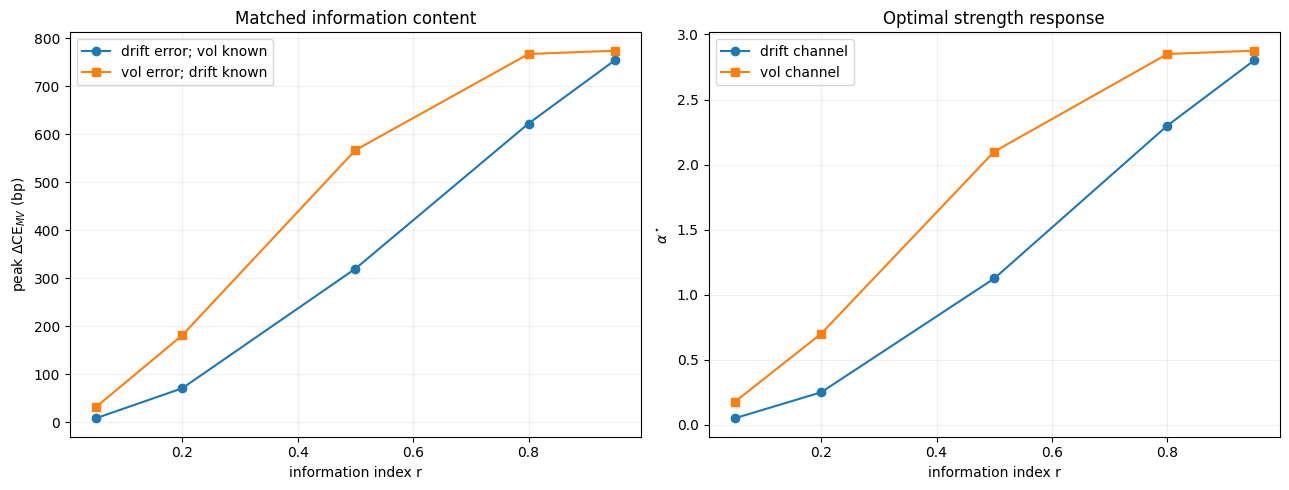

     r|  drift dCE  alpha*|   vol dCE  alpha*|  vol-drift  paired SE
  0.95|      754.2    2.80|     773.7    2.88|       19.5       26.8
  0.80|      622.1    2.30|     766.9    2.85|      144.8       21.3
  0.50|      319.9    1.12|     566.7    2.10|      246.9       14.0
  0.20|       71.1    0.25|     181.3    0.70|      110.3       15.2
  0.05|        8.5    0.05|      31.4    0.18|       22.9        4.5
log-vol dispersion index d=0.2744; clipped-normal prior means r is an information-matching index, not an exact posterior weight


In [72]:
rng_vol=np.random.default_rng(4343)
sigma_bar,sigma_sig=0.20,0.05
sig_i=np.clip(sigma_bar+sigma_sig*rng_vol.standard_normal((n_sims,N)),0.05,None)
eta0=rng_vol.standard_normal((n_sims,N))
R_het=np.exp((mu-.5*sig_i**2)*dt+sig_i*np.sqrt(dt)*phi)-1
var_bar=np.mean(sig_i**2)  # exact simulated prior mean after clipping
d_logvol=np.log(sig_i).std()
s36=mu+sigma_eps_base*eps0
alpha_g36=np.linspace(0,8,321)

r_levels=[.95,.8,.5,.2,.05]
nums_drift={}; nums_vol={}
for r in r_levels:
    fac=np.sqrt((1-r)/r)
    nums_drift[r]=(mu+sigma_mu*fac*eps0)/sig_i**2
    nu=d_logvol*fac
    sh=sig_i*np.exp(nu*eta0-.5*nu**2)
    nums_vol[r]=mu/sh**2
all_masks=[normaliser_mask_from_num(x) for x in list(nums_drift.values())+list(nums_vol.values())]
common36_i=np.logical_and.reduce(all_masks)
print(f"part (i) common sample: retained {common36_i.sum()}, dropped {(~common36_i).sum()}")
rows_drift=[best_alpha(nums_drift[r],R_het,alpha_g36,common36_i) for r in r_levels]
rows_vol=[best_alpha(nums_vol[r],R_het,alpha_g36,common36_i) for r in r_levels]

fig,axes=plt.subplots(1,2,figsize=(13,5)); ax=axes[0]
ax.plot(r_levels,[x[0] for x in rows_drift],'o-',label='drift error; vol known')
ax.plot(r_levels,[x[0] for x in rows_vol],'s-',label='vol error; drift known')
ax.set(xlabel='information index r',ylabel=r'peak $\Delta$CE$_{MV}$ (bp)',title='Matched information content')
ax.grid(alpha=.2); ax.legend(); ax=axes[1]
ax.plot(r_levels,[x[1] for x in rows_drift],'o-',label='drift channel')
ax.plot(r_levels,[x[1] for x in rows_vol],'s-',label='vol channel')
ax.set(xlabel='information index r',ylabel=r'$\alpha^\star$',title='Optimal strength response')
ax.grid(alpha=.2); ax.legend(); plt.tight_layout(); plt.show()

print(f"{'r':>6}|{'drift dCE':>11}{'alpha*':>8}|{'vol dCE':>10}{'alpha*':>8}|{'vol-drift':>11}{'paired SE':>11}")
for r,a,b in zip(r_levels,rows_drift,rows_vol):
    pd=portfolio_from_num(nums_drift[r],a[1],R_het,common36_i)
    pv=portfolio_from_num(nums_vol[r],b[1],R_het,common36_i)
    gap,se=paired_block_ce(pv,pd)
    print(f"{r:>6.2f}|{a[0]:>11.1f}{a[1]:>8.2f}|{b[0]:>10.1f}{b[1]:>8.2f}|{gap:>11.1f}{se:>11.1f}")
print(f"log-vol dispersion index d={d_logvol:.4f}; clipped-normal prior means r is an information-matching index, not an exact posterior weight")


### Part (ii) — Reliability-motivated shrinkage

The second part crosses two drift treatments—raw and reliability-shrunk—with three volatility treatments—ignored, raw, and reliability-shrunk. This produces six configurations on one common retained sample. Strength is re-optimised for each configuration.

Drift shrinkage follows the Gaussian reliability coefficient. Volatility processing uses reliability on the log-volatility scale to motivate shrinkage of the variance input towards its prior centre. Because the volatility prior is not log-Gaussian, this is a practical reliability-based rule rather than an exact Bayesian posterior mean. Paired contrasts isolate the contribution of each processing choice.

part (ii) common sample: retained 29646, dropped 354
kappa_mu=0.50; reliability-motivated kappa_sigma=0.65

                                   vol IGNORED               vol RAW            vol SHRUNK
               drift RAW         370 bp a=1.30          242 bp a=0.80          409 bp a=1.40 
            drift SHRUNK         474 bp a=3.73          348 bp a=2.50          480 bp a=3.58 

paired contrasts
shrink drift, vol raw                         +106.2 bp  (paired SE 10.1)
shrink vol, drift raw                         +167.2 bp  (paired SE 10.0)
use best vol, drift shrunk                      +6.3 bp  (paired SE 4.7)


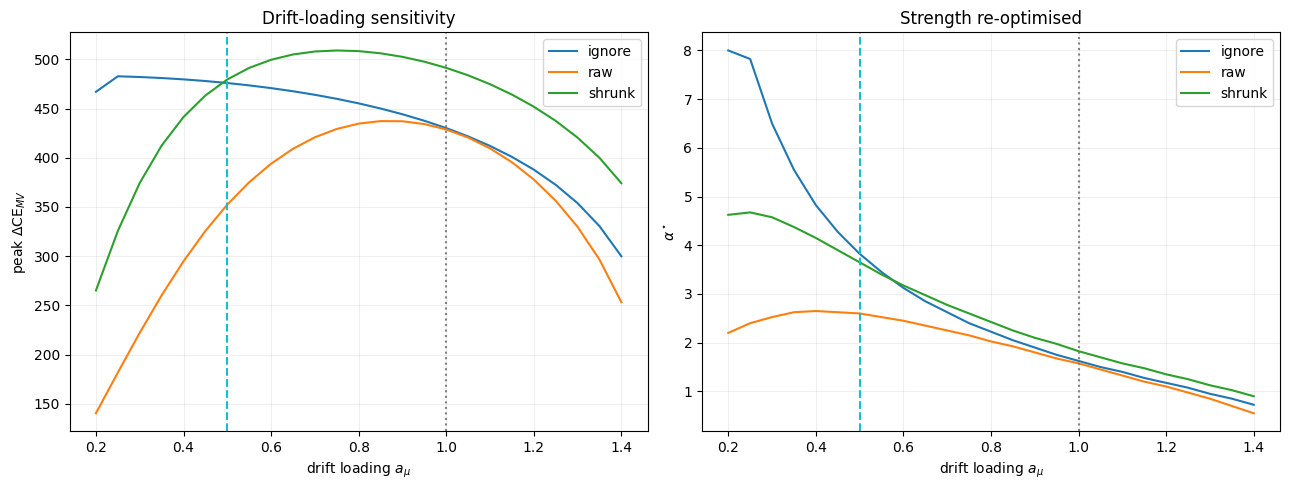

In [73]:
nu_36=.20
sighat=sig_i*np.exp(nu_36*eta0-.5*nu_36**2)
kappa_mu=sigma_mu**2/(sigma_mu**2+sigma_eps_base**2)
kappa_vol=d_logvol**2/(d_logvol**2+nu_36**2)
vol_levels=[('ignore',0.0),('raw',1.0),('shrunk',kappa_vol)]
drift_levels=[('raw',1.0),('shrunk',kappa_mu)]
nums36={(lm,lv):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar))
        for lm,am in drift_levels for lv,av in vol_levels}
common36_ii=np.logical_and.reduce([normaliser_mask_from_num(x) for x in nums36.values()])
cells={key:best_alpha(num,R_het,alpha_g36,common36_ii) for key,num in nums36.items()}
print(f"part (ii) common sample: retained {common36_ii.sum()}, dropped {(~common36_ii).sum()}")
print(f"kappa_mu={kappa_mu:.2f}; reliability-motivated kappa_sigma={kappa_vol:.2f}\n")
print(f"{'':>24}{'vol IGNORED':>22}{'vol RAW':>22}{'vol SHRUNK':>22}")
for lm,_ in drift_levels:
    lab='drift RAW' if lm=='raw' else 'drift SHRUNK'
    rr=[cells[(lm,lv)] for lv,_ in vol_levels]
    print(f"{lab:>24}"+''.join(f"{x[0]:>12.0f} bp a={x[1]:<5.2f}" for x in rr))

def report_pair(label,key_a,key_b):
    a,b=cells[key_a],cells[key_b]
    pa=portfolio_from_num(nums36[key_a],a[1],R_het,common36_ii)
    pb=portfolio_from_num(nums36[key_b],b[1],R_het,common36_ii)
    gap,se=paired_block_ce(pa,pb)
    print(f"{label:<44}{gap:+8.1f} bp  (paired SE {se:.1f})")
print("\npaired contrasts")
report_pair('shrink drift, vol raw',('shrunk','raw'),('raw','raw'))
report_pair('shrink vol, drift raw',('raw','shrunk'),('raw','raw'))
report_pair('use best vol, drift shrunk',('shrunk','shrunk'),('shrunk','ignore'))

amu_g=np.linspace(.2,1.4,25)
curve_nums={(am,lv):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar)) for am in amu_g for lv,av in vol_levels}
common_curve=np.logical_and.reduce([normaliser_mask_from_num(x) for x in curve_nums.values()])
curves={lv:[best_alpha(curve_nums[(am,lv)],R_het,alpha_g36,common_curve) for am in amu_g] for lv,_ in vol_levels}
fig,axes=plt.subplots(1,2,figsize=(13,5)); ax=axes[0]
for lv,rows in curves.items(): ax.plot(amu_g,[x[0] for x in rows],label=lv)
ax.axvline(kappa_mu,color='tab:cyan',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'drift loading $a_\mu$',ylabel=r'peak $\Delta$CE$_{MV}$',title='Drift-loading sensitivity'); ax.grid(alpha=.2); ax.legend()
ax=axes[1]
for lv,rows in curves.items(): ax.plot(amu_g,[x[1] for x in rows],label=lv)
ax.axvline(kappa_mu,color='tab:cyan',ls='--'); ax.axvline(1,color='grey',ls=':')
ax.set(xlabel=r'drift loading $a_\mu$',ylabel=r'$\alpha^\star$',title='Strength re-optimised'); ax.grid(alpha=.2); ax.legend()
plt.tight_layout(); plt.show()


### Part (iii) — Joint loading search

The final part introduces separate loadings for the drift and volatility inputs in addition to the overall strength $\alpha$. A grid search evaluates the resulting objective surface and records the best strength for every loading pair.

The purpose is to determine whether the individual input loadings are sharply identified or whether different combinations produce similar portfolio weights after $\alpha$ is re-optimised. The output therefore reports not only peak CE but also the geometry of the objective surface and portfolio-level comparisons between representative points along any high-performing ridge.

In [74]:
amu_g3,avol_g3=np.linspace(.30,1.10,9),np.linspace(0,1,11)
nums_grid={(round(am,2),round(av,2)):(mu_bar+am*(s36-mu_bar))/(var_bar+av*(sighat**2-var_bar)) for am in amu_g3 for av in avol_g3}
common36_iii=np.logical_and.reduce([normaliser_mask_from_num(x) for x in nums_grid.values()])
grid3={key:best_alpha(num,R_het,alpha_g36,common36_iii)[:2] for key,num in nums_grid.items()}
(g_am,g_av),(g_d,g_al)=max(grid3.items(),key=lambda kv:kv[1][0])
print(f"common sample retained {common36_iii.sum()}, dropped {(~common36_iii).sum()}")
print(f"three-parameter optimum: a_mu={g_am:.2f}, a_sigma={g_av:.2f}, alpha={g_al:.2f}, dCE_MV={g_d:.1f} bp")

def theta_deficit(w):
    wt=np.abs(w); wt/=wt.sum(axis=1,keepdims=True)
    with np.errstate(divide='ignore',invalid='ignore'): H=-np.where(wt>0,wt*np.log(wt),0).sum(axis=1)
    return 1-H/np.log(N)
def portfolio36(am,av,al):
    num=nums_grid[(round(am,2),round(av,2))]; ns=num[common36_iii].sum(axis=1)
    w=(1-al)/N+al*num[common36_iii]/ns[:,None]
    return w,np.abs(w).sum(axis=1).mean(),theta_deficit(w).mean()

print(f"{'a_mu':>6}{'a_sigma*':>10}{'alpha*':>9}{'dCE_MV':>11}{'leverage':>10}{'theta':>8}")
ridge=[]
for am in amu_g3[:4]:
    sub={kk:v for kk,v in grid3.items() if kk[0]==round(am,2)}; key=max(sub,key=lambda kk:sub[kk][0]); d,a=sub[key]
    w,lev,th=portfolio36(am,key[1],a); ridge.append((am,key[1],a,w))
    print(f"{am:>6.2f}{key[1]:>10.2f}{a:>9.2f}{d:>11.1f}{lev:>10.2f}{th:>8.3f}")
w1,w2=ridge[0][3],ridge[-1][3]
print(f"weight correlation across ridge endpoints: {np.corrcoef(w1.ravel(),w2.ravel())[0,1]:.4f}")
print(f"mean |weight difference|: {np.abs(w1-w2).mean():.4f} (equal weight={1/N:.3f})")


common sample retained 29238, dropped 762
three-parameter optimum: a_mu=0.50, a_sigma=0.30, alpha=3.95, dCE_MV=513.5 bp
  a_mu  a_sigma*   alpha*     dCE_MV  leverage   theta
  0.30      0.10     6.65      505.9      2.36   0.093
  0.40      0.20     4.98      511.5      2.38   0.095
  0.50      0.30     3.95      513.5      2.39   0.098
  0.60      0.40     3.25      512.3      2.38   0.102
weight correlation across ridge endpoints: 0.9782
mean |weight difference|: 0.0213 (equal weight=0.050)


## Experiment III — Comparison of the Two Maps

Experiment III compares softmax and combination at their respective CE-optimal strengths. Both maps use the same returns and drift signals, and softmax is evaluated on the combination map's retained sample so that every reported difference is paired.

The experiment has two volatility settings. Part (i) retains the common volatility $\sigma_i=0.20$ and examines uncorrelated, equicorrelated, and three-factor Brownian increments. This isolates the effect of correlation. Under common volatility and equicorrelation, covariance inversion changes the scale of the combination portfolio's tilt but not its cross-sectional direction; every fully invested portfolio also retains the same exposure to the common Brownian component.

Part (ii) repeats the comparison with heterogeneous volatilities redrawn in each replication. For equicorrelation,

$$
\Sigma_r=\operatorname{diag}(\sigma_r)C(\rho)\operatorname{diag}(\sigma_r).
$$

Unequal volatilities allow covariance inversion to change both the scale and direction of the signal-implied portfolio. The combination map receives the true simulated covariance matrix, while softmax continues to use only the drift signal. Within each part, the two maps share returns, signals, and retained replications.

The code reports each map's optimal strength and peak M--V CE, their paired difference, leverage and concentration diagnostics, and threshold sensitivity for the heterogeneous-volatility comparison. The purpose is a controlled head-to-head comparison rather than a claim that either map is uniformly superior.

In [75]:
rho_levels=[0.0,.25,.5]; rng_corr=np.random.default_rng(4242); z0=rng_corr.standard_normal((n_sims,1))
k_fac=3; rng_fac=np.random.default_rng(7); B=np.empty((N,k_fac)); B[:,0]=.45+.15*rng_fac.standard_normal(N); B[:,1:]=.30*rng_fac.standard_normal((N,k_fac-1))
norms=np.sqrt((B**2).sum(axis=1)); too_big=norms>.95; B[too_big]*=(.95/norms[too_big])[:,None]
idio=np.sqrt(1-(B**2).sum(axis=1)); F=rng_fac.standard_normal((n_sims,k_fac))
cases_hom={}
for rho in rho_levels:
    C=(1-rho)*np.eye(N)+rho*np.ones((N,N)); ph=np.sqrt(rho)*z0+np.sqrt(1-rho)*phi
    cases_hom[fr'equicorr $\rho={rho}$']=(C,ph)
C_fac=B@B.T+np.diag(idio**2); cases_hom['factor model']=(C_fac,F@B.T+phi*idio)
case_data_hom={}
for name,(C,ph) in cases_hom.items():
    Sinv=np.linalg.inv(sigma**2*C*dt); num=s_base@Sinv.T
    Rc=np.exp((mu-.5*sigma**2)*dt+sigma*np.sqrt(dt)*ph)-1
    case_data_hom[name]=(Sinv,num,Rc,normaliser_mask_from_num(num))
common37_hom=np.logical_and.reduce([x[3] for x in case_data_hom.values()])
print(f'Part (i), common volatility: retained {common37_hom.sum()}, dropped {(~common37_hom).sum()}')
print(f"{'case':>22}{'a*':>7}{'comb peak':>12}{'b*':>6}{'sfmx peak':>12}{'gap':>9}{'gap SE':>9}{'own drops':>11}{'gross p99':>10}{'short p99':>10}")
summary37_hom={}
for name,(Sinv,num,Rc,ownmask) in case_data_hom.items():
    sc=s_base[common37_hom]; rcm=Rc[common37_hom]
    ce_c,_,_=ce_sweep(sc,alpha_grid,rcm,Sinv); a,_,kc=alpha_star(alpha_grid,ce_c)
    ce_s=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(ce_s))
    cp=1e4*(ce_c[kc]-ce_c[0]); sp=1e4*(ce_s[ks]-ce_s[0])
    wsig=num[common37_hom]/num[common37_hom].sum(axis=1,keepdims=True); wheld=(1-a)/N+a*wsig
    p_comb=(wheld*rcm).sum(axis=1); p_soft=(softmax_weights(sc,beta_grid[ks])*rcm).sum(axis=1)
    _,gap_se=paired_block_ce(p_comb,p_soft)
    held_g99=np.quantile(np.abs(wheld).sum(axis=1),.99); held_s99=np.quantile(np.maximum(-wheld,0).sum(axis=1),.99)
    summary37_hom[name]=(cp,sp,a,beta_grid[ks]); clean=name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>22}{a:>7.2f}{cp:>12.1f}{beta_grid[ks]:>6.0f}{sp:>12.1f}{cp-sp:>9.1f}{gap_se:>9.1f}{(~ownmask).sum():>11}{held_g99:>10.2f}{held_s99:>10.2f}")



Part (i), common volatility: retained 29557, dropped 443
                  case     a*   comb peak    b*   sfmx peak      gap   gap SE  own drops gross p99 short p99
      equicorr rho=0.0   1.37       387.5    18       266.1    121.4      4.0         41      5.09      2.04
     equicorr rho=0.25   0.21       440.1    21       283.8    156.3      8.8         41      5.97      2.48
      equicorr rho=0.5   0.10       526.7    26       312.3    214.3     15.5         41      7.74      3.37
          factor model   0.19       267.0    20       273.1     -6.1     10.2        411      6.52      2.76


Part (ii), heterogeneous volatility: retained 26565, dropped 3435
                  case     a*   comb peak    b*   sfmx peak      gap   gap SE  own drops gross p99 short p99
      equicorr rho=0.0   0.95       269.9    18       255.9     14.1      7.8        231      6.17      2.59
     equicorr rho=0.25   0.11       125.4    20       275.8   -150.4     12.0       1102      4.84      1.92
      equicorr rho=0.5   0.07       129.2    25       304.1   -175.0     16.4       1545      5.00      2.00
          factor model   0.18       170.4    19       264.1    -93.8     11.9        989      5.78      2.39


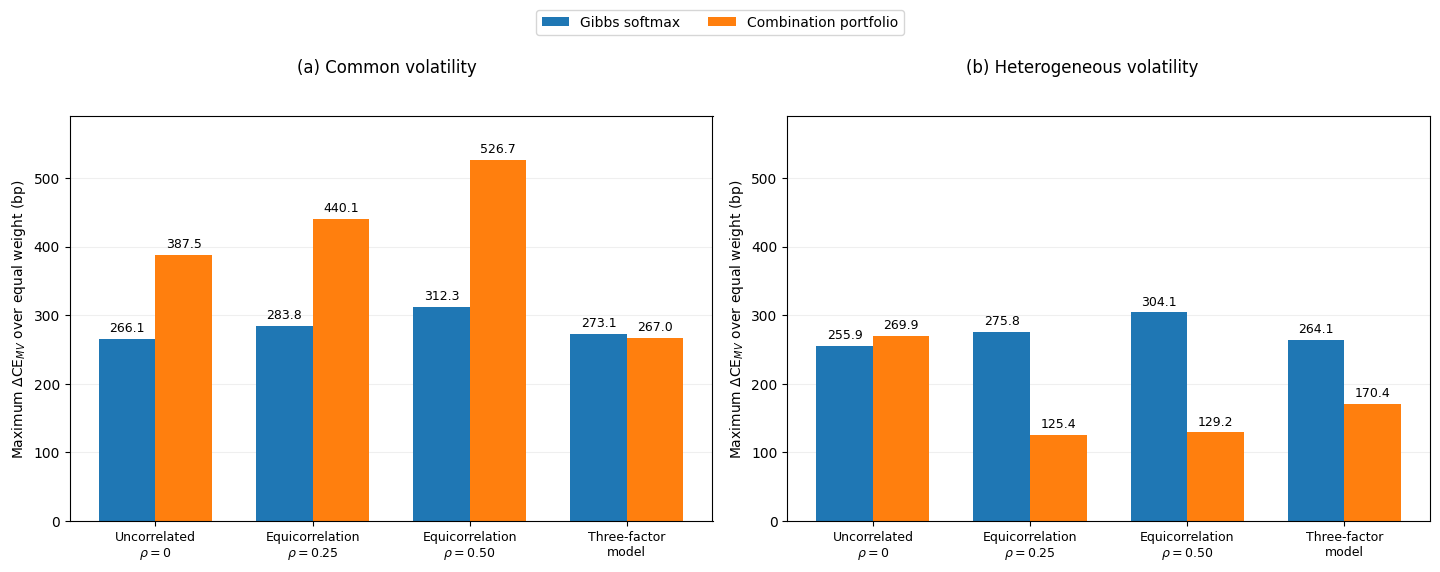


normaliser-threshold sensitivity: combination-minus-softmax gap (bp)
 threshold  retained      equicorr rho=0.0     equicorr rho=0.25      equicorr rho=0.5          factor model
        5%     28174                 -78.7                -203.4                -250.5                -166.9
       10%     26565                  14.1                -150.4                -175.0                 -93.8
       20%     24085                 120.0                  12.7                  44.6                  47.8


In [76]:
rho_levels=[0.0,.25,.5]; rng_corr=np.random.default_rng(4242); z0=rng_corr.standard_normal((n_sims,1))
k_fac=3; rng_fac=np.random.default_rng(7); B=np.empty((N,k_fac)); B[:,0]=.45+.15*rng_fac.standard_normal(N); B[:,1:]=.30*rng_fac.standard_normal((N,k_fac-1))
norms=np.sqrt((B**2).sum(axis=1)); too_big=norms>.95; B[too_big]*=(.95/norms[too_big])[:,None]
idio=np.sqrt(1-(B**2).sum(axis=1)); F=rng_fac.standard_normal((n_sims,k_fac))
cases={}
for rho in rho_levels:
    C=(1-rho)*np.eye(N)+rho*np.ones((N,N)); ph=np.sqrt(rho)*z0+np.sqrt(1-rho)*phi
    cases[fr'equicorr $\rho={rho}$']=(C,ph)
C_fac=B@B.T+np.diag(idio**2); cases['factor model']=(C_fac,F@B.T+phi*idio)
case_data={}
for name,(C,ph) in cases.items():
    Cinv=np.linalg.inv(C)
    # Sigma_r^{-1}s_r = D_r^{-1} C^{-1} D_r^{-1}s_r / dt, with D_r=diag(sigma_r).
    num=((s_base/sig_i)@Cinv.T)/sig_i/dt
    Rc=np.exp((mu-.5*sig_i**2)*dt+sig_i*np.sqrt(dt)*ph)-1
    case_data[name]=(C,Cinv,num,Rc,normaliser_mask_from_num(num))
common37=np.logical_and.reduce([x[4] for x in case_data.values()])
print(f"Part (ii), heterogeneous volatility: retained {common37.sum()}, dropped {(~common37).sum()}")
print(f"{'case':>22}{'a*':>7}{'comb peak':>12}{'b*':>6}{'sfmx peak':>12}{'gap':>9}{'gap SE':>9}{'own drops':>11}{'gross p99':>10}{'short p99':>10}")
summary={}
for name,(C,Cinv,num,Rc,ownmask) in case_data.items():
    sc=s_base[common37]; rcm=Rc[common37]
    wsig=num[common37]/num[common37].sum(axis=1,keepdims=True)
    p_eq=rcm.mean(axis=1); p_sig=(wsig*rcm).sum(axis=1)
    ce_c=mv_blend_curve(p_eq,p_sig,alpha_grid); a,_,kc=alpha_star(alpha_grid,ce_c)
    ce_s=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(ce_s))
    cp=1e4*(ce_c[kc]-ce_c[0]); sp=1e4*(ce_s[ks]-ce_s[0])
    p_comb=(1-a)*p_eq+a*p_sig
    p_soft=(softmax_weights(sc,beta_grid[ks])*rcm).sum(axis=1)
    _,gap_se=paired_block_ce(p_comb,p_soft)
    wheld=(1-a)/N+a*wsig
    held_g99=np.quantile(np.abs(wheld).sum(axis=1),.99)
    held_s99=np.quantile(np.maximum(-wheld,0).sum(axis=1),.99)
    summary[name]=(cp,sp,a,beta_grid[ks]); clean=name.replace('$','').replace('\\rho','rho')
    print(f"{clean:>22}{a:>7.2f}{cp:>12.1f}{beta_grid[ks]:>6.0f}{sp:>12.1f}{cp-sp:>9.1f}{gap_se:>9.1f}{(~ownmask).sum():>11}{held_g99:>10.2f}{held_s99:>10.2f}")

names=list(summary); names_hom=list(summary37_hom); x=np.arange(len(names)); wd=.36
tick_labels=['Uncorrelated\n'+r'$\rho=0$','Equicorrelation\n'+r'$\rho=0.25$','Equicorrelation\n'+r'$\rho=0.50$','Three-factor\nmodel']
fig,axes=plt.subplots(1,2,figsize=(14.5,5.8),sharey=True)
for ax,data,case_names,title in [
    (axes[0],summary37_hom,names_hom,'(a) Same volatility for all assets'),
    (axes[1],summary,names,'(b) Different volatilities across assets')]:
    bars_s=ax.bar(x-wd/2,[data[n][1] for n in case_names],wd,label='Gibbs softmax')
    bars_c=ax.bar(x+wd/2,[data[n][0] for n in case_names],wd,label='Combination portfolio')
    ax.bar_label(bars_s,fmt='%.1f',padding=3,fontsize=9)
    ax.bar_label(bars_c,fmt='%.1f',padding=3,fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(tick_labels,fontsize=9)
    ax.grid(axis='y',alpha=.2); ax.set_axisbelow(True)
    ax.tick_params(axis='y',labelleft=True)
    ax.set_ylabel(r'Maximum $\Delta$CE$_{MV}$ over equal weight (bp)')
ymax=1.12*max(max(v[0],v[1]) for data in [summary37_hom,summary] for v in data.values())
axes[0].set_ylim(0,ymax)
fig.text(.27,.87,'(a) Common volatility',ha='center',fontsize=12)
fig.text(.75,.87,'(b) Heterogeneous volatility',ha='center',fontsize=12)
handles,labels=axes[0].get_legend_handles_labels()
fig.legend(handles,labels,loc='upper center',ncol=2,bbox_to_anchor=(.5,.99))
plt.tight_layout(rect=[0,0,1,.82])
plt.savefig('experiment7_map_comparison.png',dpi=300,bbox_inches='tight')
plt.show()

print('\nnormaliser-threshold sensitivity: combination-minus-softmax gap (bp)')
case_labels=[name.replace('$','').replace('\\rho','rho') for name in cases]
print(f"{'threshold':>10}{'retained':>10}"+''.join(f"{label:>22}" for label in case_labels))
for thr in [0.05,0.10,0.20]:
    mt=np.logical_and.reduce([normaliser_mask_from_num(x[2],thr) for x in case_data.values()])
    gaps=[]
    for name,(C,Cinv,num,Rc,ownmask) in case_data.items():
        sc=s_base[mt]; rcm=Rc[mt]; ws=num[mt]/num[mt].sum(axis=1,keepdims=True)
        p0=rcm.mean(axis=1); ps=(ws*rcm).sum(axis=1)
        cc=mv_blend_curve(p0,ps,alpha_grid); kc=int(np.argmax(cc))
        cs=np.array([ce_of(softmax_weights(sc,b),rcm) for b in beta_grid]); ks=int(np.argmax(cs))
        gaps.append(1e4*((cc[kc]-cc[0])-(cs[ks]-cs[0])))
    print(f"{thr:>10.0%}{mt.sum():>10}"+''.join(f"{gap:>22.1f}" for gap in gaps))


## Methodology

All experiments use the common M--V CE evaluator and common random numbers. Combination-map results apply the stated normaliser-domain rule, and cross-setting comparisons use intersection masks so alternatives are evaluated on identical retained replications. Threshold sensitivity is reported where conclusions depend materially on the domain choice.

Strength and loading searches use explicit grids with endpoint checks. The volatility shrinkage rule is described as reliability-motivated rather than as an exact posterior calculation, and the joint-loading exercise assesses identification numerically rather than assuming it. Correlation experiments distinguish common from heterogeneous volatility because covariance inversion has different directional effects in the two cases.

The notebook retains the numerical tables, figures, paired diagnostics, and implementation checks needed to reproduce Experiments II and III. Longer interpretation is kept in the dissertation rather than duplicated in the code submission.